# 🛢️ Proyecto: Selección Óptima de Pozos Petrolíferos para OilyGiant

## 📌 Objetivo del proyecto

La empresa **OilyGiant** busca identificar la mejor región para desarrollar **200 nuevos pozos petrolíferos**, maximizando la rentabilidad y minimizando el riesgo de pérdidas.

Para lograrlo, se utilizarán datos geológicos de tres regiones con información sobre las características de cada pozo y el volumen de reservas disponibles. A partir de estos datos, se construirá un modelo predictivo que permita estimar las reservas de nuevos pozos y seleccionar las ubicaciones más prometedoras.

---

## 🎯 Objetivos específicos

- ✅ Analizar y preparar los datos de exploración geológica.
- ✅ Entrenar modelos de **Regresión Lineal** para estimar el volumen de reservas de petróleo.
- ✅ Evaluar el desempeño de los modelos mediante el **RMSE** y el volumen promedio predicho.
- ✅ Seleccionar los **200 pozos más prometedores** dentro de una muestra de 500 ubicaciones por región.
- ✅ Calcular el beneficio potencial de cada región considerando costos e ingresos esperados.
- ✅ Aplicar la técnica de **Bootstrapping (1000 simulaciones)** para evaluar la incertidumbre de las ganancias.
- ✅ Determinar la región óptima para la inversión considerando rentabilidad y riesgo.

---

## 💰 Supuestos económicos del proyecto

Para evaluar la viabilidad financiera de cada región se consideran las siguientes condiciones:

🔹 **Inversión total disponible:** \$100 millones USD para el desarrollo de 200 pozos.

🔹 **Proceso de selección:** en cada región se analizarán 500 ubicaciones potenciales y únicamente se elegirán los 200 pozos con mayor volumen estimado de reservas.

🔹 **Valor de producción:** cada barril de petróleo genera aproximadamente **\$4.5 USD** de ingresos.

🔹 **Conversión utilizada en los datos:** dado que las reservas están expresadas en miles de barriles, cada unidad de producto equivale a **\$4,500 USD** de ingresos.

🔹 **Punto de equilibrio:** para recuperar la inversión, cada pozo debe producir en promedio al menos **111.1 mil barriles** de petróleo recuperable.

🔹 **Criterio de decisión:** únicamente se considerarán viables las regiones cuyo riesgo de pérdidas sea inferior al **2.5%**. Entre ellas, se seleccionará aquella con el mayor beneficio esperado.

---

## 📂 Descripción de los datos

El análisis se realiza a partir de tres conjuntos de datos sintéticos correspondientes a distintas regiones de exploración petrolera:

📁 `geo_data_0.csv`

📁 `geo_data_1.csv`

📁 `geo_data_2.csv`

Cada observación representa un pozo petrolero e incluye la siguiente información:

🆔 **id** → Identificador único del pozo.

📍 **f0, f1 y f2** → Variables geológicas utilizadas para caracterizar cada ubicación de exploración. Aunque su significado específico no se proporciona, contienen información relevante para la predicción de reservas.

🛢️ **product** → Volumen de reservas estimadas en el pozo, expresado en miles de barriles de petróleo.

---

## 🔬 Metodología

### 1️⃣ Preparación de los datos
- Carga y exploración inicial de las bases de datos.
- Verificación de calidad de los datos.
- Preparación de variables para el modelado.

### 2️⃣ Entrenamiento y evaluación de modelos
- División de los datos en conjuntos de entrenamiento (75%) y validación (25%).
- Entrenamiento de un modelo de **Regresión Lineal** para cada región.
- Obtención de predicciones sobre el conjunto de validación.
- Evaluación mediante el **Error Cuadrático Medio (RMSE)**.

### 3️⃣ Cálculo de ganancias potenciales
- Selección de los 200 pozos con mayor volumen predicho.
- Estimación del volumen total de reservas recuperables.
- Cálculo de los beneficios potenciales para cada región.

### 4️⃣ Análisis de riesgo
- Aplicación de la técnica de **Bootstrapping** con 1000 muestras.
- Estimación de la distribución de ganancias.
- Cálculo del beneficio promedio esperado.
- Construcción de intervalos de confianza del 95%.
- Estimación de la probabilidad de pérdidas.

### 5️⃣ Toma de decisión
- Comparación de las tres regiones.
- Evaluación conjunta de rentabilidad y riesgo.
- Selección de la región óptima para la inversión.

---

## ❓ Pregunta de investigación

> **¿Cuál de las tres regiones ofrece la mejor combinación entre rentabilidad esperada y bajo riesgo para desarrollar 200 nuevos pozos petrolíferos?**

### 🏆 Resultado esperado

Al finalizar el proyecto se recomendará la región con el mayor potencial económico, considerando tanto el beneficio promedio esperado como el riesgo asociado a la inversión.

## Etapa 1: Preprocesamiento de Datos

In [ ]:
# Se importan las librerías.
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import mean_squared_error
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    mean_squared_error,
    r2_score,
    mean_absolute_error
)
from sklearn.utils import shuffle
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [2]:
# Se cargan los datos de las tres regiones respectivas y echa un vistazo a la estructuración de los dataframes respectivos. 
reg1 = pd.read_csv('/datasets/geo_data_0.csv')
reg2 = pd.read_csv('/datasets/geo_data_1.csv')
reg3 = pd.read_csv('/datasets/geo_data_2.csv')

In [3]:
reg1.head()

,id,f0,f1,f2,product
0,txEyH,0.705745,-0.497823,1.221170,105.280062
1,2acmU,1.334711,-0.340164,4.365080,73.037750
2,409Wp,1.022732,0.151990,1.419926,85.265647
3,iJLyR,-0.032172,0.139033,2.978566,168.620776
4,Xdl7t,1.988431,0.155413,4.751769,154.036647


In [4]:
reg2.head()

,id,f0,f1,f2,product
0,kBEdx,-15.001348,-8.276000,-0.005876,3.179103
1,62mP7,14.272088,-3.475083,0.999183,26.953261
2,vyE1P,6.263187,-5.948386,5.001160,134.766305
3,KcrkZ,-13.081196,-11.506057,4.999415,137.945408
4,AHL4O,12.702195,-8.147433,5.004363,134.766305


In [5]:
reg3.head()

,id,f0,f1,f2,product
0,fwXo0,-1.146987,0.963328,-0.828965,27.758673
1,WJtFt,0.262778,0.269839,-2.530187,56.069697
2,ovLUW,0.194587,0.289035,-5.586433,62.871910
3,q6cA6,2.236060,-0.553760,0.930038,114.572842
4,WPMUX,-0.515993,1.716266,5.899011,149.600746


In [6]:
# Se observa más en detalle cada una de las variables componentes del dataframe. Aparentemente ninguna tiene valores ausentes y no presentan problemas en
# su tipo de dato.
reg1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB


In [7]:
reg2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB


In [8]:
reg3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB


In [9]:
# Procede a verificarse que no haya datos ausentes ni duplicados de manera más controlada. 
reg1.isna().sum()

id         0
f0         0
f1         0
f2         0
product    0
dtype: int64

In [10]:
reg2.isna().sum()

id         0
f0         0
f1         0
f2         0
product    0
dtype: int64

In [11]:
reg3.isna().sum()

id         0
f0         0
f1         0
f2         0
product    0
dtype: int64

In [12]:
reg1.duplicated().sum()

0

In [13]:
reg2.duplicated().sum()

0

In [14]:
reg3.duplicated().sum()

0

In [15]:
# Vale la pena examinar si los identificadores de cada pozo no están duplicados también. 
reg1.duplicated(subset='id').sum()

10

In [16]:
# Encontramos anteriormente que, efectivamente, hay identificadores duplicados. Por lo tanto, es necesario examinar cuáles son estos y si su duplicación 
# se extiende a toda la fila.
reg1[reg1.duplicated(subset='id')]

,id,f0,f1,f2,product
7530,HZww2,1.061194,-0.373969,10.430210,158.828695
41724,bxg6G,-0.823752,0.546319,3.630479,93.007798
51970,A5aEY,-0.180335,0.935548,-2.094773,33.020205
63593,QcMuo,0.635635,-0.473422,0.862670,64.578675
66136,74z30,1.084962,-0.312358,6.990771,127.643327
69163,AGS9W,-0.933795,0.116194,-3.655896,19.230453
75715,Tdehs,0.112079,0.430296,3.218993,60.964018
90815,fiKDv,0.049883,0.841313,6.394613,137.346586
92341,TtcGQ,0.110711,1.022689,0.911381,101.318008
97785,bsk9y,0.378429,0.005837,0.160827,160.637302


In [17]:
# Aquí podemos observar que no se extiende la duplicación a toda la fila. Esto nos indica que fue más bien un error en la recodificación de los valores
# de la variable 'id', pues se tratan de dos pozos distintos. Ahora veamos que esto se repita en las demás regiones. 
reg1.query("id == 'HZww2'")

,id,f0,f1,f2,product
931,HZww2,0.755284,0.368511,1.863211,30.681774
7530,HZww2,1.061194,-0.373969,10.430210,158.828695


In [18]:
reg2.duplicated(subset='id').sum()

4

In [19]:
reg2[reg2.duplicated(subset='id')]

,id,f0,f1,f2,product
41906,LHZR0,-8.989672,-4.286607,2.009139,57.085625
82178,bfPNe,-6.202799,-4.820045,2.995107,84.038886
82873,wt4Uk,10.259972,-9.376355,4.994297,134.766305
84461,5ltQ6,18.213839,2.191999,3.993869,107.813044


In [20]:
reg2.query("id == 'LHZR0'")

,id,f0,f1,f2,product
1305,LHZR0,11.170835,-1.945066,3.002872,80.859783
41906,LHZR0,-8.989672,-4.286607,2.009139,57.085625


In [21]:
reg3.duplicated(subset='id').sum()

4

In [22]:
reg3[reg3.duplicated(subset='id')]

,id,f0,f1,f2,product
43233,xCHr8,-0.847066,2.101796,5.597130,184.388641
49564,VF7Jo,-0.883115,0.560537,0.723601,136.233420
55967,KUPhW,1.211150,3.176408,5.543540,132.831802
95090,Vcm5J,2.587702,1.986875,2.482245,92.327572


In [23]:
reg3.query("id == 'xCHr8'")

,id,f0,f1,f2,product
28039,xCHr8,1.633027,0.368135,-2.378367,6.120525
43233,xCHr8,-0.847066,2.101796,5.597130,184.388641


In [24]:
# Como pudo apreciarse, en las tres regiones existe el mismo problema de codificación de los valores en la variable 'id'. Por lo tanto, nos deshacemos 
# de esta columna, ya que puede ocasionar futuras confusiones y por el momento no es esencial para el análisis. 
reg1.drop('id', axis=1, inplace=True)
reg1.head()

,f0,f1,f2,product
0,0.705745,-0.497823,1.221170,105.280062
1,1.334711,-0.340164,4.365080,73.037750
2,1.022732,0.151990,1.419926,85.265647
3,-0.032172,0.139033,2.978566,168.620776
4,1.988431,0.155413,4.751769,154.036647


In [25]:
reg2.drop('id', axis=1, inplace=True)
reg2.head()

,f0,f1,f2,product
0,-15.001348,-8.276000,-0.005876,3.179103
1,14.272088,-3.475083,0.999183,26.953261
2,6.263187,-5.948386,5.001160,134.766305
3,-13.081196,-11.506057,4.999415,137.945408
4,12.702195,-8.147433,5.004363,134.766305


In [26]:
reg3.drop('id', axis=1, inplace=True)
reg3.head()

,f0,f1,f2,product
0,-1.146987,0.963328,-0.828965,27.758673
1,0.262778,0.269839,-2.530187,56.069697
2,0.194587,0.289035,-5.586433,62.871910
3,2.236060,-0.553760,0.930038,114.572842
4,-0.515993,1.716266,5.899011,149.600746


## Etapa 2: Análisis Exploratorio de Datos (EDA)
---
Empezamos con el análisis exploratorio de los datos (EDA). Aquí cabe mencionar, antes de proceder, que los dataframes no ofrecen muchas posibilidades para hacer un EDA demasiado complejo, ya que, salvo product, se desconoce qué signifiquen las demas características. Por motivos didácticos meramente, estaremos interpretando las columnas 'f0', 'f1' y'f2' como las coordenadas de cada pozo; es decir, latitud, longitud y profundidad del pozo.

### Región 1

<AxesSubplot:xlabel='product', ylabel='Count'>

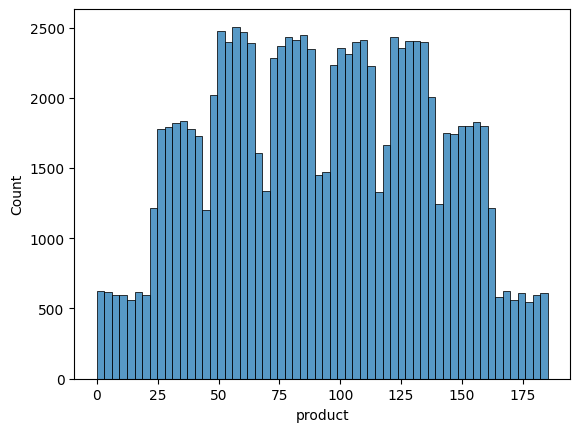

In [27]:
sns.histplot(reg1['product'])

<AxesSubplot:ylabel='product'>

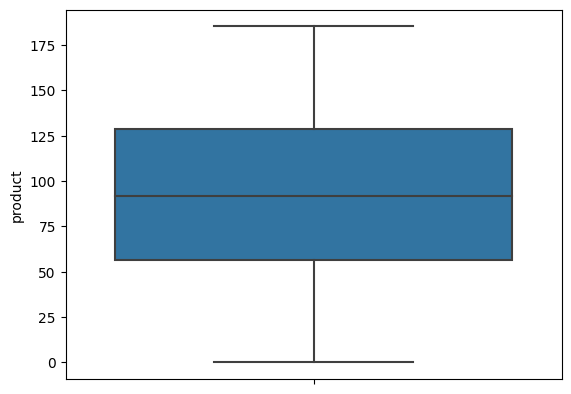

In [28]:
sns.boxplot(y=reg1['product'])

In [29]:
print(reg1['product'].describe()) 

count    100000.000000
mean         92.500000
std          44.288691
min           0.000000
25%          56.497507
50%          91.849972
75%         128.564089
max         185.364347
Name: product, dtype: float64


In [30]:
# El describe nos da las estadísticas fundamentales de nuestros datos. No hay problema con ello. 
# Sin embargo, al momento de observar su ordenación, vemos hay muchos valores próximos, sólo distanciados 
# por los decimales. Esto último dificulta varías cuestiones. En términos técnicos, implementar un value_counts,
# por ejemplo, que pueda agregar valores iguales y contar las observaciones que reunen en el dataframe. 
# En términos de comprensión de los objetivos, esto último significa un obstáculo para saber con exactitud 
# cuántos pozos tuvieron 0 o 185 mil barriles de petróleo extraído. Esto es importante saberlo por el tema de 
# los outliers; es decir, asegurarse, por poner un caso, que la cifra mínima de 0 máxima de 185 mil bárriles no sean 
# datos atípicos que puedan estar engañando nuestra percepción y toma de decisiones. Por lo tanto, es necesario
# transformar esta columna truncando sus valores, para que puedan contarse de manera precisa, en primer lugar, 
# cuántos pozos no alcanzaron los mil barriles, por un lado, y cuáles llegaron al valor máximo de 185 mil, 
# por el otro. De momento, sólo es necesario saber esto y no complicarse demasiado con los demás valores.

print(reg1['product'].sort_values(ascending=False))

8826     185.364347
99818    185.362690
94175    185.355615
1925     185.354980
45291    185.352015
            ...    
55969      0.021781
5105       0.009428
58769      0.006114
97721      0.004022
57263      0.000000
Name: product, Length: 100000, dtype: float64


In [31]:

truncados_reg1 = reg1['product']
truncados_reg1 = np.trunc(truncados_reg1)
truncados_reg1 = truncados_reg1.astype('int')
truncados_reg1 = truncados_reg1.value_counts(ascending=False).reset_index()
truncados_reg1.rename({'index':'barriles (miles)', 
                         'product':'pozos'},
                        axis=1,
                        inplace=True
                       )
truncados_reg1.sort_values(by='barriles (miles)', inplace=True)
condicion_1 = truncados_reg1['barriles (miles)'] == 0
condicion_2 = truncados_reg1['barriles (miles)'] == 185
min_max_count = truncados_reg1[condicion_1 | condicion_2]
print(f"La cantidad de pozos que no llegaron a los mil barriles extraídos (valor mínimo) y aquellos que alcanzaron los 185 mil (valor máximo) es la siguiente:\n{min_max_count.reset_index(drop=True)}")


La cantidad de pozos que no llegaron a los mil barriles extraídos (valor mínimo) y aquellos que alcanzaron los 185 mil (valor máximo) es la siguiente:
   barriles (miles)  pozos
0                 0    194
1               185     75


En la primera región, es posible apreciar una distribución bastante variada en lo que se refiere al volumen de reservas en los pozos registrados. Sin embargo, podemos decir que el 50% central de los pozos en nuestra distribución ronda entre los 56 y 128 mil barriles de petróleo extraídos. Por otro lado, es posible igualmente afirmar que en la región 1 se encontraron en promedio 92 mil barriles de petróleo. Ahora bien, el valor mínimo es 0 y para contar el número de pozos que poseyeran esta característica tuvimos que hacer algunos cambios. Ante todo, fue preciso truncar los decimales, lo cual significa que pozos que tanto no llegaron a los mil barriles extraídos como aquellos en donde no se encontró ninguna reserva fueron interpretados bajo una sóla categoría, "0", la cual denota que no alcanzaron a la unidad mínima de mil barriles. Finalmente, en cuanto a la cantidad de pozos registrados con el valor máximo de 185 mil barriles extraídos, se contabilizaron 75. 

### Región 2

<AxesSubplot:xlabel='product', ylabel='Count'>

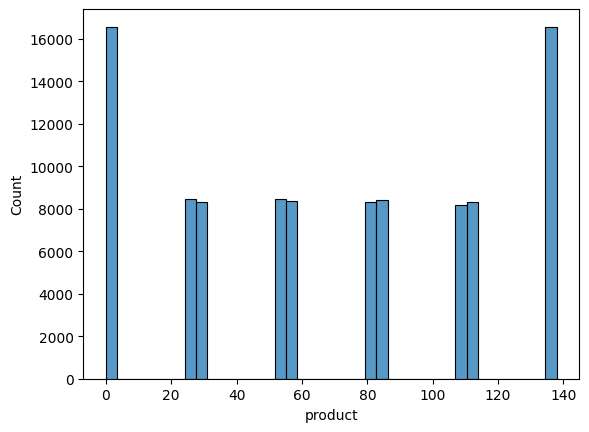

In [32]:
sns.histplot(reg2['product'])

<AxesSubplot:ylabel='product'>

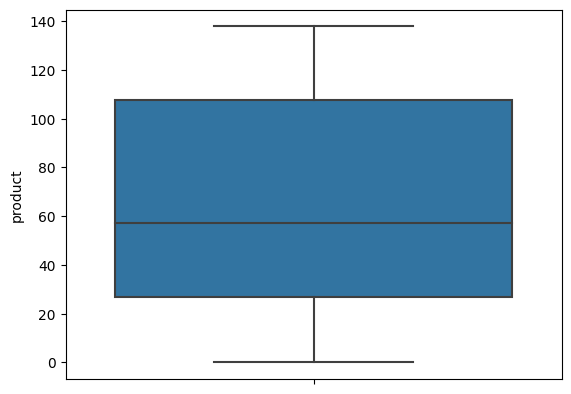

In [33]:
sns.boxplot(y=reg2['product'])

In [34]:
print(reg2['product'].describe())

count    100000.000000
mean         68.825000
std          45.944423
min           0.000000
25%          26.953261
50%          57.085625
75%         107.813044
max         137.945408
Name: product, dtype: float64


In [35]:
print(reg2['product'].sort_values(ascending=False))
print(reg2['product'].value_counts())

53864    137.945408
97083    137.945408
88340    137.945408
64879    137.945408
7288     137.945408
            ...    
67767      0.000000
36443      0.000000
36430      0.000000
67776      0.000000
42537      0.000000
Name: product, Length: 100000, dtype: float64
53.906522     8472
26.953261     8468
84.038886     8431
57.085625     8390
3.179103      8337
80.859783     8320
30.132364     8306
134.766305    8304
110.992147    8303
0.000000      8235
137.945408    8233
107.813044    8201
Name: product, dtype: int64


La región 2 muestra una distribución un tanto extraña. Los valores extremos, mínimo y máximo, son los que presentan la mayor cantidad de observaciones, mientras que los valores que están entre medio se encuentran bastante nivelados en cuanto a su frecuencia. Esto último quiere decir que la cantidad de pozos desde los cuales se extrajeron entre 26-30, 53-57, 80-84, y 107-110 miles de barriles es prácticamente la misma o muy aproximada. Por otro lado, llama la atención que el volumen de reservas en múltiples filas es exactamente el mismo, como lo muestra la función sort_values. Esto nos hace sospechar sobre la forma en que se recopilaron y registraron los datos para esta región, en cuanto que difiere de las otras dos. También vale la pena destacar que en esta región se encontraron, a diferencia de la anterior, 8,235 pozos sin ninguna reserva. 

Tomando en cuenta todo esto, es posible afirmar que el 50% centro de los pozos en la distribución posee entre 26 y 107 miles de barriles de petroleo extraídos. En promedio, en esta región son extraídos 68 mil barriles de petróleo y la cantidad máxima de barriles de petróleo que registra es de 137 mil.

### Región 3

<AxesSubplot:xlabel='product', ylabel='Count'>

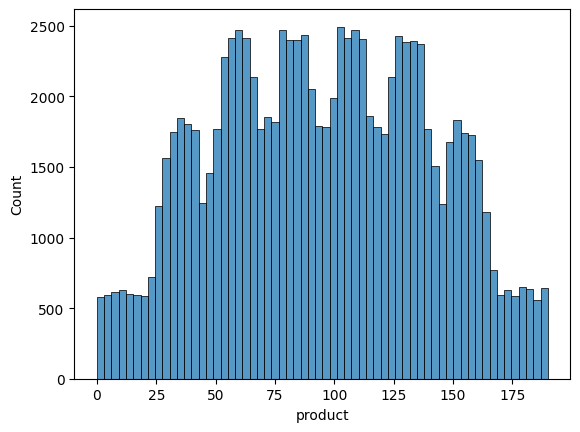

In [36]:
sns.histplot(reg3['product'])

<AxesSubplot:ylabel='product'>

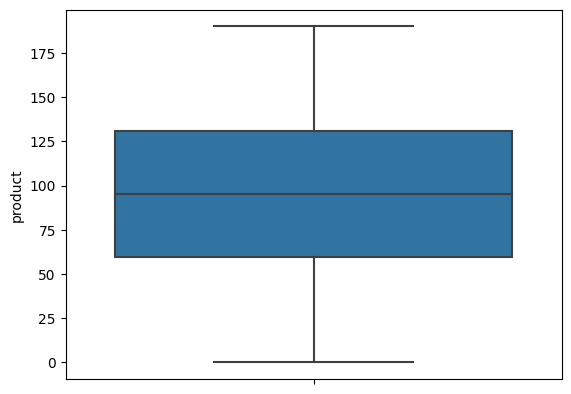

In [37]:
sns.boxplot(y=reg3['product'])

In [38]:
print(reg3['product'].describe())

count    100000.000000
mean         95.000000
std          44.749921
min           0.000000
25%          59.450441
50%          94.925613
75%         130.595027
max         190.029838
Name: product, dtype: float64


In [39]:
# La región 3 presenta la misma problemática que la región 1, como es posible apreciarlo con este value counts. 
# Por tanto, es preciso proceder de la misma forma para averiguar la cantidad de pozos con 0 reservas y 190 mil barriles extraídos. 
print(reg3['product'].sort_values(ascending=False))

79705    190.029838
93444    190.013589
35099    190.011722
21943    190.010982
37870    190.010029
            ...    
39815      0.014039
31253      0.009761
32261      0.009204
43452      0.004606
68149      0.000000
Name: product, Length: 100000, dtype: float64


In [40]:
truncados_reg3 = reg3['product']
truncados_reg3 = np.trunc(truncados_reg3)
truncados_reg3 = truncados_reg3.astype('int')
truncados_reg3 = truncados_reg3.value_counts(ascending=False).reset_index()
truncados_reg3.rename({'index':'barriles (miles)', 
                         'product':'pozos'},
                        axis=1,
                        inplace=True
                       )
truncados_reg3.sort_values(by='barriles (miles)', inplace=True)
condicion_1_r3 = truncados_reg3['barriles (miles)'] == 0
condicion_2_r3 = truncados_reg3['barriles (miles)'] == 190
min_max_count_r3 = truncados_reg3[condicion_1_r3 | condicion_2_r3]
print(f"La cantidad de pozos que no llegaron a los mil barriles extraídos (valor mínimo) y aquellos que alcanzaron los 190 mil (valor máximo) es la siguiente:\n{min_max_count_r3.reset_index(drop=True)}")

La cantidad de pozos que no llegaron a los mil barriles extraídos (valor mínimo) y aquellos que alcanzaron los 190 mil (valor máximo) es la siguiente:
   barriles (miles)  pozos
0                 0    191
1               190      5


En promedio, en la región 3 se extrayeron 95 mil barriles de petróleo, estos es, tres mil más que en la región 1. El 50% central de los pozos en nuestra distribución ronda entre los 59 y 130 mil barriles extraídos. Su valor mínimo es de cero, pero a diferencia de la región 2, sólo hubo 191 pozos donde no se llegó a la unidad básica de 1000 barriles de petróleo. Por otro lado, el valor máximo de 190 mil barriles extraídos puede decirse que es bastante extremo, registrándose tan sólo 5 pozos con dicha cantidad de reservas. 

## Etapa 3: Análisis de Datos: Modelos de Machine Learning por Región

### Region 1

In [41]:
# Hacemos la división inicial entre las características y la variable objetivo
features_reg1 = reg1.drop('product', axis=1)
target_reg1 = reg1['product']

In [42]:
# Procedemos a subdivirlas en los conjuntos de entrenamiento y validación

features_train_r1, features_valid_r1, target_train_r1, target_valid_r1 = train_test_split(features_reg1, 
                                                                                          target_reg1, 
                                                                                          test_size=0.25, 
                                                                                          random_state=12345
                                                                                         )
print(features_valid_r1.shape)
print(target_valid_r1.shape)

(25000, 3)
(25000,)


In [43]:
# Se crea el modelo y entrena, además de generar las estimaciones de las reservas de petróleos.
model_lr_1 = LinearRegression()
model_lr_1.fit(features_train_r1, target_train_r1)
pred_1 = model_lr_1.predict(features_valid_r1)

In [44]:
# Se calcula el error cuadrático medio y le aplicamos la raíz cuadrada para tener la métrica en la escala original.
# Vemos que el error en la predicción es de 37.5 mil barriles
sme_r1 = mean_squared_error(target_valid_r1, pred_1)
r2_score_reg1 = r2_score(target_valid_r1, pred_1)
mae_r1 = mean_absolute_error(target_valid_r1, pred_1)
print(np.sqrt(sme_r1))
print(r2_score_reg1)
print(mae_r1)

37.5794217150813
0.27994321524487786
30.919600777151313


In [45]:
# Ordenamos los 200 mejores pozos que predice el modelo
pred_1 = pd.Series(pred_1, index=target_valid_r1.index)
pred_1_ord = pred_1.sort_values(ascending=False)
print(pred_1_ord.head(10))
pred_1_top200 = pred_1_ord[0:200]
print(pred_1_top200.shape)

# Ya que tenmos los 200 pozos con mayores reservas de petróleo estimadas, sumamos todos los valores para obtener el 
# volumen total de reservas estimadas de acuerdo con el conjunto de validación. Igualmente sacamos promedio para calcular
# el volumen promedio.
voltotal_predvalid_r1 = pred_1_top200.sum()
volmean_predvalid_r1 = pred_1_top200.mean()

93073    180.180713
46784    176.252213
78948    175.850623
43388    175.658429
6496     173.299686
93716    172.627972
99628    172.501678
11404    169.124234
74946    168.787602
95898    168.206015
dtype: float64
(200,)


In [46]:
print(f"El volumen total de reservas predicho por el modelo para los 200 mejores pozos de extracción es el siguiente:\n{voltotal_predvalid_r1}")
print(f"El volumen promedio de reservas predicho por el modelo para los 200 mejores pozos de extracción es el siguiente:\n{volmean_predvalid_r1}")

El volumen total de reservas predicho por el modelo para los 200 mejores pozos de extracción es el siguiente:
31102.3308388114
El volumen promedio de reservas predicho por el modelo para los 200 mejores pozos de extracción es el siguiente:
155.511654194057


In [47]:
# Pasamos al cálculo de las ganancias tanto estimadas como reales. Dado que el ingreso de una unidad de producto 
# (mil barriles de petróleo) genera 4,500 dólares de ingreso, es pertinente multiplicar el volumen total (estimado y real)
# por esta última cantidad, para luego restarle el presupuesto de los 100,000,000 de dólares. De esta manera, sabremos 
# si habrá algún retorno sobre la inversión o, por el contrario, pérdidas. 
ganancia_estimada = (voltotal_predvalid_r1 * 4500) - 100000000
print(f"La ganancia estimada de la extracción de petróleo de los 200 pozos con mejores reservas es:\n{round(ganancia_estimada, 2)} dólares")

voltotal_realvalid_r1 = target_valid_r1[pred_1_top200.index]
voltotal_realvalid_r1 = voltotal_realvalid_r1.sum()

ganancia_real = (voltotal_realvalid_r1 * 4500) - 100000000
print(f"La ganancia real de la extracción de petróleo de los 200 pozos con mejores reservas es:\n{round(ganancia_real, 2)} dólares")

La ganancia estimada de la extracción de petróleo de los 200 pozos con mejores reservas es:
39960488.77 dólares
La ganancia real de la extracción de petróleo de los 200 pozos con mejores reservas es:
33208260.43 dólares


In [48]:
# Finalmente procedemos con el cálculo de los intervalos de confianza y el riesgo. Aquí se usará la 
# técnica de bootstrapping. Esto se debe a que el valor puntual de ganancia real obtenido anteriormente debe ser sometido a 
# prueba y contrastado con otros posibles resultados obtenidos a partir de muestras distintas del mismo conjunto de datos. 
# En consecuencia, procederemos a realizar un cálculo de la ganancia real tomando como base 1,000 submuestras diferentes. 
# Esto último nos posibilitará calcular el intervalo de confianza del 95% y el porcentaje de riesgo. Cabe recordar que para 
# calcular el riesgo es importante sólo tomar los valores negativos, que son ganancias negativas o pérdidas, y dividirlas entre
# los mil resultados obtenidos. 

state = np.random.RandomState(12345)
valores_ganancia_real = []
for i in range(1000):
    submuestra = pred_1.sample(n=500, replace=True, random_state=state)
    submuestra_ord = submuestra.sort_values(ascending=False)
    pred_1_top200 = submuestra_ord[0:200]
    voltotal_realvalid_r1 = target_valid_r1[pred_1_top200.index]
    voltotal_realvalid_r1 = voltotal_realvalid_r1.sum()
    ganancia_real = (voltotal_realvalid_r1 * 4500) - 100000000 # Aquí se resta mil porque es la cantidad que constituye la inversión.
    valores_ganancia_real.append(ganancia_real)                # Por tanto, si el resultado de la resta es negativo, eso significa que hubieron perdidas,
                                                               # mientras que el signo positivo vendría a connotar las ganancias. 

print(f"El promedio de las diferentes ganancias reales obtenidas es: {np.mean(valores_ganancia_real)}")

# Construcción de los intervalos de confianza: 
lower = np.percentile(valores_ganancia_real, 2.5)
upper = np.percentile(valores_ganancia_real, 97.5)

print(f"Con un 95% de confianza, la ganancia real estará entre esos dos valores:\n{lower:.2f} millones de dólares y {upper:.2f} millónes de dolares")
print()
print(f"Es decir, que en el peor de los escenarios se podrían perder 1112155.46 millones de dólares, mientras que en el más optimista, ganar 9097669.42 millones de dólares")


El promedio de las diferentes ganancias reales obtenidas es: 3961649.8480237117
Con un 95% de confianza, la ganancia real estará entre esos dos valores:
-1112155.46 millones de dólares y 9097669.42 millónes de dolares

Es decir, que en el peor de los escenarios se podrían perder 1112155.46 millones de dólares, mientras que en el más optimista, ganar 9097669.42 millones de dólares


In [49]:
valores_ganancia_real = pd.Series(valores_ganancia_real)
negativos_ganancia = valores_ganancia_real < 0
riesgo = negativos_ganancia.mean()
print(f"El riesgo o probabilidad de pérdida de dinero es equivalente al:\n{riesgo * 100: .2f}%")

El riesgo o probabilidad de pérdida de dinero es equivalente al:
 6.90%


In [50]:
# Definición de función para automatizar el proceso para las otras dos regiones:
def volumen_totalymedio_reservas(features, target):
    features_train, features_valid, target_train, target_valid = train_test_split(features,  
                                                                                  target, 
                                                                                  test_size=0.25, 
                                                                                  random_state=12345
                                                                                 )
    model_lr = LinearRegression()
    model_lr.fit(features_train, target_train)
    pred = model_lr.predict(features_valid)
    sme = mean_squared_error(target_valid, pred)
    r2_score_metric = r2_score(target_valid, pred)
    mae = mean_absolute_error(target_valid, pred)
    pred = pd.Series(pred, index=target_valid.index)
    pred_ord = pred.sort_values(ascending=False)
    pred_top200 = pred_ord[0:200]
    voltotal_predvalid = pred_top200.sum()
    volmean_predvalid = pred_top200.mean()
    
    return target_valid, sme, r2_score_metric, mae, pred, pred_top200, voltotal_predvalid, volmean_predvalid                                                                        

### Región 2

In [51]:
# Se procede a aplicar el mismo procedimiento para la región 2.
features_reg2 = reg2.drop('product', axis=1)
target_reg2 = reg2['product']

In [52]:
target_valid_2, sme_r2, r2_score_reg2, mae_r2, pred_r2, pred_top200_r2, voltotal_predvalid_r2, volmean_predvalid_r2 = volumen_totalymedio_reservas(features_reg2, target_reg2)

In [53]:
print(f"El volumen total de reservas predicho por el modelo para los 200 mejores pozos de extracción es el siguiente:\n{voltotal_predvalid_r2}")
print(f"El volumen promedio de reservas predicho por el modelo para los 200 mejores pozos de extracción es el siguiente:\n{volmean_predvalid_r2}")

El volumen total de reservas predicho por el modelo para los 200 mejores pozos de extracción es el siguiente:
27746.026782163426
El volumen promedio de reservas predicho por el modelo para los 200 mejores pozos de extracción es el siguiente:
138.73013391081713


In [54]:
ganancia_estimada_r2 = (voltotal_predvalid_r2 * 4500) - 100000000
print(f"La ganancia estimada de la extracción de petróleo de los 200 pozos con mejores reservas es:\n{round(ganancia_estimada_r2, 2)} dólares")

voltotal_realvalid_r2 = target_valid_2[pred_top200_r2.index]
voltotal_realvalid_r2 = voltotal_realvalid_r2.sum()

ganancia_real_r2 = (voltotal_realvalid_r2 * 4500) - 100000000
print(f"La ganancia real de la extracción de petróleo de los 200 pozos con mejores reservas es:\n{round(ganancia_real_r2, 2)} dólares")

La ganancia estimada de la extracción de petróleo de los 200 pozos con mejores reservas es:
24857120.52 dólares
La ganancia real de la extracción de petróleo de los 200 pozos con mejores reservas es:
24150866.97 dólares


In [55]:
# Calcular riesgo

state_2 = np.random.RandomState(54321)
valores_ganancia_real_r2 = []
for i in range(1000):
    submuestra = pred_r2.sample(n=500, replace=True, random_state=state_2)
    submuestra_ord = submuestra.sort_values(ascending=False)
    pred_top200_r2 = submuestra_ord[0:200]
    voltotal_realvalid_r2 = target_valid_2[pred_top200_r2.index]
    voltotal_realvalid_r2 = voltotal_realvalid_r2.sum()
    ganancia_real_r2 = (voltotal_realvalid_r2 * 4500) - 100000000
    valores_ganancia_real_r2.append(ganancia_real_r2)
    
print(f"El promedio de las diferentes ganancias reales obtenidas es: {np.mean(valores_ganancia_real_r2)}")

# Construcción de los intervalos de confianza 
lower_r2 = np.percentile(valores_ganancia_real_r2, 2.5)
upper_r2 = np.percentile(valores_ganancia_real_r2, 97.5)

print(f"Con un 95% de confianza, la ganancia real estará entre esos dos valores:\n{lower_r2:.2f} millones de dólares y {upper_r2:.2f} millónes de dolares")
print()
print(f"Es decir, que en el peor de los escenarios se podrían ganar 338267.29 millones de dólares, mientras que en el más optimista, ganar 8465670.69 millones de dólares")


El promedio de las diferentes ganancias reales obtenidas es: 4373341.519785659
Con un 95% de confianza, la ganancia real estará entre esos dos valores:
338267.29 millones de dólares y 8465670.69 millónes de dolares

Es decir, que en el peor de los escenarios se podrían ganar 338267.29 millones de dólares, mientras que en el más optimista, ganar 8465670.69 millones de dólares


In [56]:
valores_ganancia_real_r2 = pd.Series(valores_ganancia_real_r2)
negativos_ganancia_r2 = valores_ganancia_real_r2 < 0
riesgo_r2 = negativos_ganancia_r2.mean()
print(f"El riesgo o probabilidad de pérdida de dinero es equivalente al:\n{riesgo_r2 * 100: .2f}%")

El riesgo o probabilidad de pérdida de dinero es equivalente al:
 1.50%


### Región 3

In [57]:
features_reg3 = reg3.drop('product', axis=1)
target_reg3 = reg3['product']

In [58]:
target_valid_3, sme_r3, r2_score_reg3, mae_r3, pred_r3, pred_top200_r3, voltotal_predvalid_r3, volmean_predvalid_r3 = volumen_totalymedio_reservas(features_reg3, target_reg3)

In [59]:
print(f"El volumen total de reservas predicho por el modelo para los 200 mejores pozos de extracción es el siguiente:\n{voltotal_predvalid_r3}")
print(f"El volumen promedio de reservas predicho por el modelo para los 200 mejores pozos de extracción es el siguiente:\n{volmean_predvalid_r3}")

El volumen total de reservas predicho por el modelo para los 200 mejores pozos de extracción es el siguiente:
29603.898658318347
El volumen promedio de reservas predicho por el modelo para los 200 mejores pozos de extracción es el siguiente:
148.01949329159174


In [60]:
ganancia_estimada_r3 = (voltotal_predvalid_r3 * 4500) - 100000000
print(f"La ganancia estimada de la extracción de petróleo de los 200 pozos con mejores reservas es:\n{round(ganancia_estimada_r3, 2)} dólares")

voltotal_realvalid_r3 = target_valid_3[pred_top200_r3.index]
voltotal_realvalid_r3 = voltotal_realvalid_r3.sum()

ganancia_real_r3 = (voltotal_realvalid_r3 * 4500) - 100000000
print(f"La ganancia real de la extracción de petróleo de los 200 pozos con mejores reservas es:\n{round(ganancia_real_r3, 2)} dólares")


La ganancia estimada de la extracción de petróleo de los 200 pozos con mejores reservas es:
33217543.96 dólares
La ganancia real de la extracción de petróleo de los 200 pozos con mejores reservas es:
27103499.64 dólares


In [61]:
# Calcular riesgo
state_3 = np.random.RandomState(54321)
valores_ganancia_real_r3 = []
for i in range(1000):
    submuestra = pred_r3.sample(n=500, replace=True, random_state=state_3)
    submuestra_ord = submuestra.sort_values(ascending=False)
    pred_top200_r3 = submuestra_ord[0:200]
    voltotal_realvalid_r3 = target_valid_3[pred_top200_r3.index]
    voltotal_realvalid_r3 = voltotal_realvalid_r3.sum()
    ganancia_real_r3 = (voltotal_realvalid_r3 * 4500) - 100000000
    valores_ganancia_real_r3.append(ganancia_real_r3)

print(f"El promedio de las diferentes ganancias reales obtenidas es: {np.mean(valores_ganancia_real_r3)}")

# Construcción de los intervalos de confianza 
lower_r3 = np.percentile(valores_ganancia_real_r3, 2.5)
upper_r3 = np.percentile(valores_ganancia_real_r3, 97.5)

print(f"Con un 95% de confianza, la ganancia real estará entre esos dos valores:\n{lower_r3:.2f} millones de dólares y {upper_r3:.2f} millónes de dolares")
print()
print(f"Es decir, que en el peor de los escenarios se podrían perder 1741311.76 millones de dólares, mientras que en el más optimista, ganar 8936564.61 millones de dólares")

El promedio de las diferentes ganancias reales obtenidas es: 3785105.6131141577
Con un 95% de confianza, la ganancia real estará entre esos dos valores:
-1741311.76 millones de dólares y 8936564.61 millónes de dolares

Es decir, que en el peor de los escenarios se podrían perder 1741311.76 millones de dólares, mientras que en el más optimista, ganar 8936564.61 millones de dólares


In [62]:
valores_ganancia_real_r3 = pd.Series(valores_ganancia_real_r3)
negativos_ganancia_r3 = valores_ganancia_real_r3 < 0
riesgo_r3 = negativos_ganancia_r3.mean()
print(f"El riesgo o probabilidad de pérdida de dinero es equivalente al:\n{riesgo_r3 * 100: .2f}%")

El riesgo o probabilidad de pérdida de dinero es equivalente al:
 9.00%


## Etapa 4: Comparación Sintética entre Resultados en Regiones

In [63]:
# Métricas de error en las predicciones de los modelos de predicción correspondientes a cada región
print("Región 1:")
print(f"Root Mean Squared Error: {np.sqrt(sme_r1)}")
print(f"R2 Score: {r2_score_reg1}")
print(f"Mean Absolut Error: {mae_r1}")
print()
print("Región 2:")
print(f"Root Mean Squared Error: {np.sqrt(sme_r2)}")
print(f"R2 Score: {r2_score_reg2}")
print(f"Mean Absolut Error: {mae_r2}")
print()
print("Región 3:")
print(f"Root Mean Squared Error: {np.sqrt(sme_r3)}")
print(f"R2 Score: {r2_score_reg3}")
print(f"Mean Absolut Error: {mae_r3}")

Región 1:
Root Mean Squared Error: 37.5794217150813
R2 Score: 0.27994321524487786
Mean Absolut Error: 30.919600777151313

Región 2:
Root Mean Squared Error: 0.893099286775617
R2 Score: 0.9996233978805127
Mean Absolut Error: 0.7187662442124758

Región 3:
Root Mean Squared Error: 40.02970873393434
R2 Score: 0.20524758386040443
Mean Absolut Error: 32.792652105481814


In [64]:
# Volumen de reservas estimadas por región:
print("Región 1:")
print(voltotal_predvalid_r1)
print()
print("Región 2:")
print(voltotal_predvalid_r2)
print()
print("Región 3:")
print(voltotal_predvalid_r3)
# Volumen de reservas reales por región:
print("Región 1:")
print(voltotal_realvalid_r1)
print()
print("Región 2:")
print(voltotal_realvalid_r2)
print()
print("Región 3:")
print(voltotal_realvalid_r3)

Región 1:
31102.3308388114

Región 2:
27746.026782163426

Región 3:
29603.898658318347
Región 1:
22710.48525251692

Región 2:
23269.510468711152

Región 3:
23368.125449500847


In [65]:
# Ganancias estimadas y reales por región
print("Región 1:")
print(f"La ganancia estimada de la extracción de petróleo de los 200 pozos con mejores reservas es:\n{round(ganancia_estimada, 2)} dólares")
print(f"La ganancia real de la extracción de petróleo de los 200 pozos con mejores reservas es:\n{round(ganancia_real, 2)} dólares")
print()
print("Región 2:")
print(f"La ganancia estimada de la extracción de petróleo de los 200 pozos con mejores reservas es:\n{round(ganancia_estimada_r2, 2)} dólares")
print(f"La ganancia real de la extracción de petróleo de los 200 pozos con mejores reservas es:\n{round(ganancia_real_r2, 2)} dólares")
print()
print("Región 3:")
print(f"La ganancia estimada de la extracción de petróleo de los 200 pozos con mejores reservas es:\n{round(ganancia_estimada_r3, 2)} dólares")
print(f"La ganancia real de la extracción de petróleo de los 200 pozos con mejores reservas es:\n{round(ganancia_real_r3, 2)} dólares")

Región 1:
La ganancia estimada de la extracción de petróleo de los 200 pozos con mejores reservas es:
39960488.77 dólares
La ganancia real de la extracción de petróleo de los 200 pozos con mejores reservas es:
2197183.64 dólares

Región 2:
La ganancia estimada de la extracción de petróleo de los 200 pozos con mejores reservas es:
24857120.52 dólares
La ganancia real de la extracción de petróleo de los 200 pozos con mejores reservas es:
4712797.11 dólares

Región 3:
La ganancia estimada de la extracción de petróleo de los 200 pozos con mejores reservas es:
33217543.96 dólares
La ganancia real de la extracción de petróleo de los 200 pozos con mejores reservas es:
5156564.52 dólares


In [66]:
# Bootstrapping: promedio de los valores correspondientes a las ganancias reales obtenidas a partir 
# de 1000 muestras o escenarios diferentes.
print("Región 1:")
print(np.mean(valores_ganancia_real))
print()
print("Región 2:")
print(np.mean(valores_ganancia_real_r2))
print()
print("Región 3:")
print(np.mean(valores_ganancia_real_r3))

Región 1:
3961649.8480237117

Región 2:
4373341.519785659

Región 3:
3785105.6131141577


In [67]:
# Intervalos de confianza con 95% de confianza para estimar las ganancias reales en cada región
print("Región 1:")
print(f"Límite inferior:{lower}, límite superior:{upper}")
print()
print("Región 2:")
print(f"Límite inferior:{lower_r2}, límite superior:{upper_r2}")
print()
print("Región 3:")
print(f"Límite inferior:{lower_r3}, límite superior:{upper_r3}")

Región 1:
Límite inferior:-1112155.4589049604, límite superior:9097669.41553423

Región 2:
Límite inferior:338267.2938230001, límite superior:8465670.692162605

Región 3:
Límite inferior:-1741311.7637829354, límite superior:8936564.613281596


In [68]:
# El riesgo de pérdida de dinero en cada región:
print("Región 1:")
print(f"{riesgo * 100}%")
print()
print("Región 2:")
print(f"{riesgo_r2 * 100}%")
print()
print("Región 3:")
print(f"{riesgo_r3 * 100}%")

Región 1:
6.9%

Región 2:
1.5%

Región 3:
9.0%


# 🔎📈 Conclusión

El objetivo de este proyecto fue identificar la región más conveniente para la apertura de **200 nuevos pozos petrolíferos**, combinando técnicas de aprendizaje automático y análisis de riesgo para respaldar una decisión de inversión basada en datos.

A través de modelos de **Regresión Lineal**, se estimó el volumen de reservas en tres regiones diferentes y se evaluó su desempeño utilizando métricas como el **RMSE** y el coeficiente de determinación (**R²**). Los resultados mostraron que la **Región 2** presentó la mayor capacidad predictiva, alcanzando un **R² cercano a 1** y el menor error de predicción entre las regiones analizadas.

Sin embargo, una decisión de inversión no puede basarse únicamente en la precisión del modelo o en las ganancias potenciales. Por esta razón, se realizó un análisis de incertidumbre mediante **Bootstrapping**, simulando 1,000 escenarios posibles para estimar la distribución de beneficios y el riesgo de pérdidas asociado a cada región.

### 📊 Hallazgos principales

✅ La **Región 2** fue la única que cumplió con el criterio corporativo de mantener un riesgo de pérdidas inferior al **2.5%**.

✅ Presentó un beneficio promedio estimado de aproximadamente **4.37 millones de dólares**, acompañado de un intervalo de confianza favorable.

✅ Las regiones 1 y 3 mostraron ganancias potenciales atractivas, pero sus probabilidades de pérdida superaron el límite aceptable, alcanzando aproximadamente **6.9%** y **9.0%**, respectivamente.

✅ La combinación de alta precisión predictiva, rentabilidad esperada y bajo riesgo convirtió a la Región 2 en la alternativa más sólida para la inversión.

### 🎯 Recomendación final

Considerando conjuntamente los resultados de predicción, las ganancias esperadas y el análisis de riesgo, se recomienda que **OilyGiant desarrolle sus nuevos pozos en la Región 2**. Esta región no solo ofrece un retorno económico competitivo, sino que también proporciona el nivel de seguridad financiera requerido para una inversión de gran escala.

En términos generales, este proyecto demuestra cómo la integración de **Machine Learning**, análisis financiero y simulaciones estadísticas puede transformar datos geológicos en información estratégica para la toma de decisiones empresariales, permitiendo seleccionar oportunidades de inversión con un equilibrio adecuado entre rentabilidad y riesgo.